In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np





In [99]:
df=pd.read_csv('../Datasets/clean_data.csv')
df.head()


,crime_rate,residential_zone_pct,industrial_pct,charles_river,nitric_oxide,avg_rooms,pre1940_pct,employment_dist,highway_access,tax_rate,pupil_teacher_ratio,black_proportion,lower_status_pct,price
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [100]:
X=df.drop('price',axis=1)
y=df['price']

In [101]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [102]:
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [103]:
print(model.coef_)      
print(model.intercept_) 

[-1.08011358e-01  4.64204584e-02  2.05586264e-02  2.68673382e+00
 -1.77666112e+01  3.80986521e+00  6.92224640e-04 -1.47556685e+00
  3.06049479e-01 -1.23345939e-02 -9.52747232e-01  9.31168327e-03
 -5.24758378e-01]
36.45948838508988


In [104]:
# Evaluate the model
r2 = model.score(X, y)
print(r2)

0.7406426641094095


In [105]:
coef_df=pd.DataFrame(model.coef_,columns=['coefficient'])
coef_df

,coefficient
0,-0.108011
1,0.046420
2,0.020559
3,2.686734
4,-17.766611
5,3.809865
6,0.000692
7,-1.475567
8,0.306049
9,-0.012335


In [106]:
predicted_values=model.predict(X_train)
residuals=(y_train-predicted_values)
residuals

477    0.457273
15     0.602517
332   -3.938880
423    0.224714
19    -0.206136
         ...   
106    2.312440
270   -1.202955
348   -3.042051
435    0.038584
102   -1.190137
Name: price, Length: 404, dtype: float64

<Axes: title={'center': 'Actual Vs Predicted Price'}, xlabel='Actual Price', ylabel='Predicted Price'>

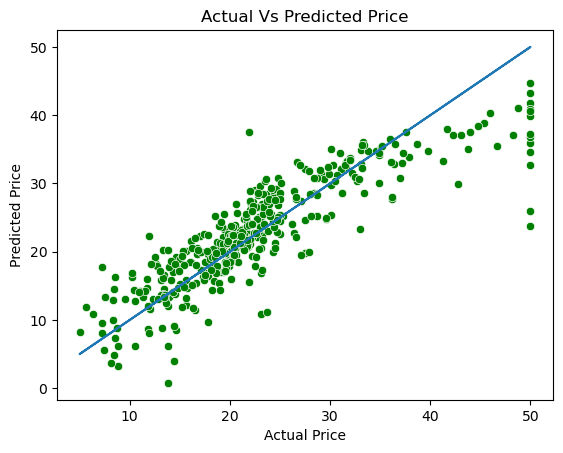

In [116]:
plt.title('Actual Vs Predicted Price')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.plot(y_train,y_train)
sns.scatterplot(
    
    y=predicted_values,
    x=y_train,
    color='green',

    
)

<Axes: title={'center': 'Predicted Values vs Residuals'}, xlabel='Predicted Values', ylabel='Residuals'>

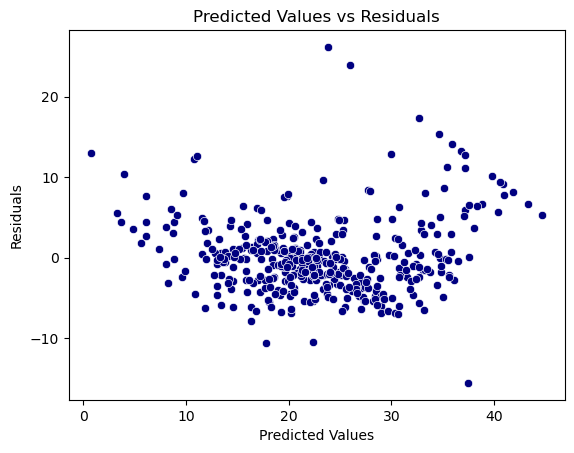

In [126]:
plt.title('Predicted Values vs Residuals')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
sns.scatterplot(
    x=predicted_values,
    y=residuals,
    color='navy'
)

Mean of the Residuals: 0.0065172888914174125
Skewness: 1.5173439609162676


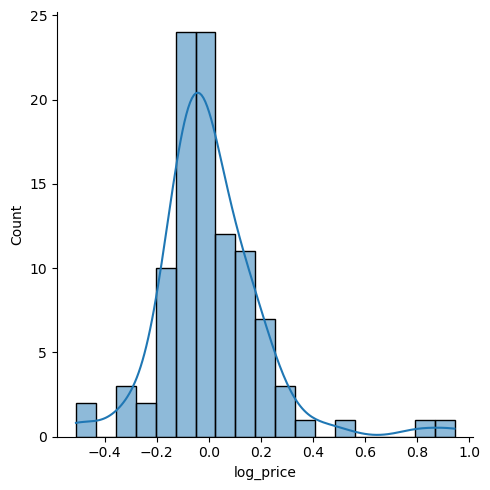

In [ ]:
print(f'Mean of the Residuals: {residuals.mean()}')
print(f'Skewness: {residuals.skew()}')
sns.displot(residuals, kde=True)


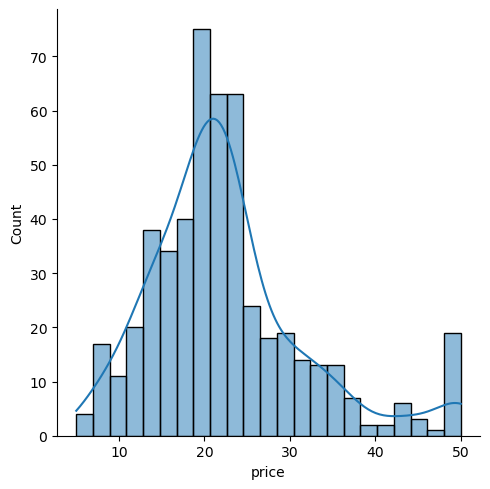

In [118]:
import seaborn as sns

sns.displot(df['price'], kde=True)

In [119]:
df['price'].skew()

np.float64(1.1080984082549072)

Train R²: 0.7957149231758659
Test R²: 0.7462724975382748
Mean of Residuals: 0.0065172888914174125
Skewness: 1.5173439609162676


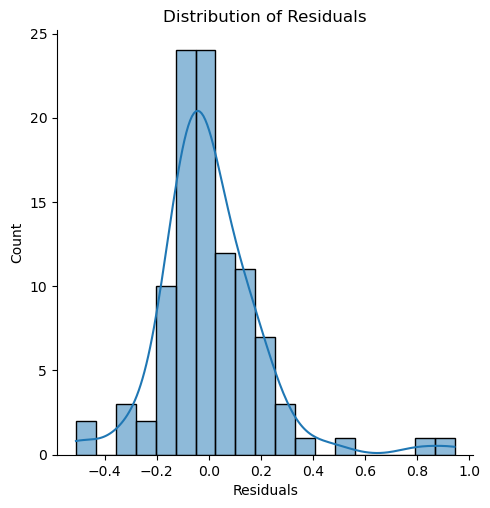

In [133]:
# Transform the "price" for better performance of the model
# 1️⃣ Create log-transformed price
df["log_price"] = np.log(df["price"])


# 2️⃣ Define features and target
X = df.drop(["price", "log_price"], axis=1)
y = df["log_price"]


# 3️⃣ Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 4️⃣ Train the model
model = LinearRegression()
model.fit(X_train, y_train)


# 5️⃣ Evaluate R² score
train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)

print("Train R²:", train_r2)
print("Test R²:", test_r2)


# 6️⃣ Make predictions
y_pred = model.predict(X_test)


# 7️⃣ Calculate residuals
residuals = y_test - y_pred


# 8️⃣ Mean and skewness of residuals
print("Mean of Residuals:", residuals.mean())
print("Skewness:", residuals.skew())


# 9️⃣ Plot residual distribution
sns.displot(residuals, kde=True)

plt.xlabel("Residuals")
plt.title("Distribution of Residuals")
plt.show()